<a href="https://colab.research.google.com/github/snigdha-ramaraju/Rock-Paper-Scissors.py/blob/main/Marketing_LSE_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# Generate synthetic marketing dataset

np.random.seed(42)

marketing_spend = np.random.randint(500, 10000, 200)

noise = np.random.randint(-2000, 2000, 200)

revenue = 5000 + 7 * marketing_spend + noise

df = pd.DataFrame({
    "Marketing_Spend": marketing_spend,
    "Revenue": revenue
})

df.head()

,Marketing_Spend,Revenue
0,7770,60201
1,1360,15522
2,5890,46185
3,5691,45287
4,6234,48007


In [4]:
df

,Marketing_Spend,Revenue
0,7770,60201
1,1360,15522
2,5890,46185
3,5691,45287
4,6234,48007
...,...,...
195,9300,70555
196,9839,72397
197,4782,39349
198,3011,25606


In [5]:
X = df[['Marketing_Spend']]
y = df['Revenue']

In [6]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [7]:
intercept = model.intercept_
slope = model.coef_[0]

print("Intercept:", intercept)
print("Slope:", slope)

Intercept: 5062.143969688528
Slope: 6.9839362621136365


In [8]:
r2 = model.score(X, y)

print("R-squared value:", r2)

R-squared value: 0.9965142269967777


In [9]:
df["Predicted_Revenue"] = model.predict(X)

df.head()

,Marketing_Spend,Revenue,Predicted_Revenue
0,7770,60201,59327.328726
1,1360,15522,14560.297286
2,5890,46185,46197.528554
3,5691,45287,44807.725237
4,6234,48007,48600.002628


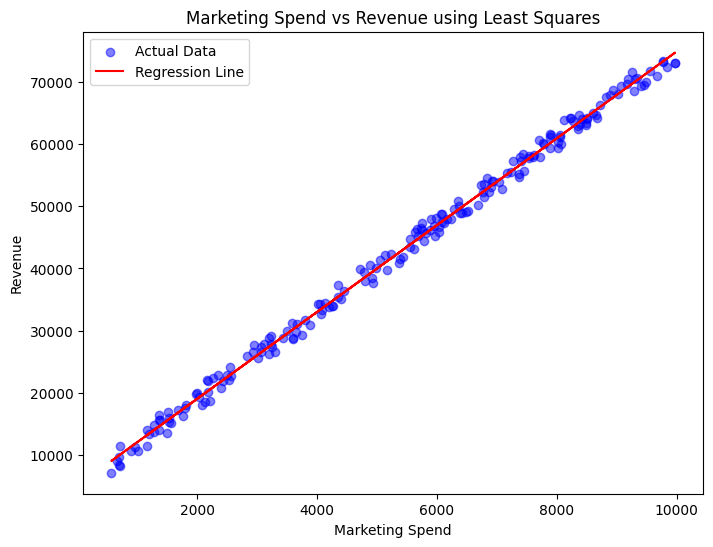

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue', alpha=0.5, label="Actual Data")

plt.plot(X, model.predict(X), color='red', label="Regression Line")

plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.title("Marketing Spend vs Revenue using Least Squares")

plt.legend()

plt.show()

In [11]:
# Calculate model accuracy using R-squared

r2 = model.score(X, y)

print("Model Accuracy (R² Score):", r2)

Model Accuracy (R² Score): 0.9965142269967777


In [12]:
# Calculate residuals

df["Residual_Error"] = df["Revenue"] - df["Predicted_Revenue"]

df.head()

,Marketing_Spend,Revenue,Predicted_Revenue,Residual_Error
0,7770,60201,59327.328726,873.671274
1,1360,15522,14560.297286,961.702714
2,5890,46185,46197.528554,-12.528554
3,5691,45287,44807.725237,479.274763
4,6234,48007,48600.002628,-593.002628


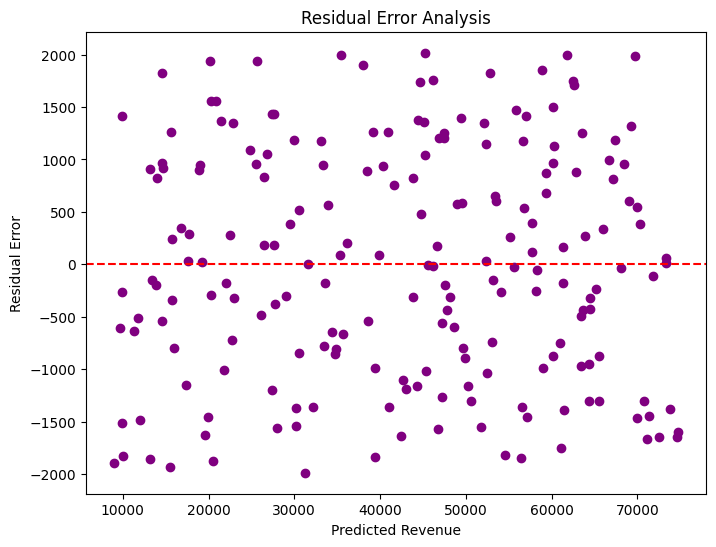

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(df["Predicted_Revenue"], df["Residual_Error"], color='purple')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Revenue")
plt.ylabel("Residual Error")
plt.title("Residual Error Analysis")

plt.show()

In [21]:
future_data = pd.DataFrame({
    "Marketing_Spend": [12000]
})

prediction = model.predict(future_data)

print("Marketing Spend:", future_data["Marketing_Spend"][0])
print("Predicted Revenue:", int(prediction[0]))

Marketing Spend: 12000
Predicted Revenue: 88869


In [22]:
# Export dataset with predictions

df.to_csv("marketing_revenue_results.csv", index=False)

print("Dataset exported successfully!")

Dataset exported successfully!


In [23]:
print("Final Regression Model:")

print(f"Revenue = {intercept:.2f} + {slope:.2f} * Marketing_Spend")

Final Regression Model:
Revenue = 5062.14 + 6.98 * Marketing_Spend


In [24]:
print("Model Accuracy (R² Score):", r2)

Model Accuracy (R² Score): 0.9965142269967777


example use-case


In [26]:
example_spend = np.array([[12000]])

predicted = model.predict(example_spend)

print("Marketing Spend:", example_spend[0][0])
print("Predicted Revenue:", int(predicted[0]))

Marketing Spend: 12000
Predicted Revenue: 88869


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
print("----- MODEL SUMMARY -----")

print(f"Intercept (a): {intercept:.2f}")
print(f"Slope (b): {slope:.2f}")

print(f"\nRegression Equation:")
print(f"Revenue = {intercept:.2f} + {slope:.2f} * Marketing_Spend")

print(f"\nModel Accuracy (R² Score): {r2:.3f}")

----- MODEL SUMMARY -----
Intercept (a): 5062.14
Slope (b): 6.98

Regression Equation:
Revenue = 5062.14 + 6.98 * Marketing_Spend

Model Accuracy (R² Score): 0.997


In [28]:
from sklearn.model_selection import train_test_split

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    df[['Marketing_Spend']], df['Revenue'],
    test_size=0.2, random_state=42
)

In [29]:
model = LinearRegression()

# Train using training dataset
model.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Squared Error: 1499046.230005679
Mean Absolute Error: 1083.6065931629396
R2 Score: 0.9941647842638602


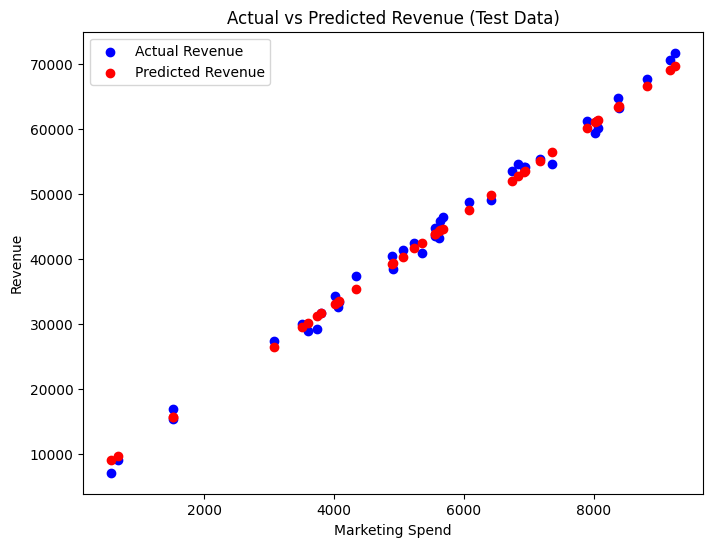

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color="blue", label="Actual Revenue")
plt.scatter(X_test, y_pred, color="red", label="Predicted Revenue")

plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.title("Actual vs Predicted Revenue (Test Data)")
plt.legend()

plt.show()

In [33]:
intercept = model.intercept_
slope = model.coef_[0]

print(f"Revenue = {intercept:.2f} + {slope:.2f} * Marketing_Spend")

Revenue = 5124.84 + 6.96 * Marketing_Spend


In [ ]:
r